# Robustness analysis: how real is the apparent edge?

This notebook documents the three-stage investigation that produced the project's headline result.

## Stage 1 — The original kaggle_v2 result on the 160-name modern-survivors universe

First-pass headline: **`lightgbm_kaggle_v2` on the curated S&P 500 subset produces IC = +0.0075 with t-stat = +2.49** over ~700k daily predictions. The cells below (bootstrap CI, decile bucket monotonicity, time-split evaluation) test whether that result holds up under standard robustness checks.

## Stage 2 — Survivorship-bias correction

After running the three checks here, we extended the universe to the PIT-correct 617-name historical S&P 500 (Wikipedia membership reconstruction). The headline IC collapsed from +0.0075 to +0.0008 (t = 0.24, not significant). **89% of the apparent edge was selection bias.**

## Stage 3 — Recovery via documented academic anomaly features

Adding three classic anomalies (Jegadeesh-Titman 12-1 momentum, Hong-Lim-Stein 52-week high, Lehmann 1-day reversal) partially recovered the edge. The anomaly cell near the bottom of this notebook runs the same robustness checks against the recovered model and shows the regime split: IC = +0.0116 in the post-October-2022 window vs. −0.0055 in the pre-2022 window — a regime-dependent edge consistent with the literature on cross-sectional anomalies strengthening during high-dispersion periods.

## Three checks, three skepticisms

1. **Bootstrap CI on IC** — resample dates with replacement, recompute mean IC. If the 5th–95th percentile band is strictly above zero, the point estimate isn't a single lucky window.
2. **Decile bucket monotonicity** — bin predictions per date into 10 buckets, plot mean realized return per bucket. A monotonic ascending staircase = real cross-sectional ranking; a flat middle with tail-only effects = the model only works in extremes.
3. **Time-split evaluation** — split walk-forward predictions in half by date and compute IC/Sharpe on each half independently. Tests for regime decay (early-sample edge that doesn't replicate later).

In [1]:
from __future__ import annotations

import polars as pl
import matplotlib.pyplot as plt

from price_model.serving.store import PredictionStore
from price_model.data.loaders import load_panel
from price_model.features.targets import add_forward_excess_return
from price_model.eval.metrics import summarize
from price_model.eval.robustness import (
    bootstrap_ic_ci,
    decile_returns,
    time_split_evaluate,
)

MODEL_ID = "lightgbm_kaggle_v2"
HORIZON = 5
UNIVERSE = "sp500"
PANEL_START = "2017-01-01"

In [1]:
from datetime import date
import polars as pl

from price_model.serving.store import PredictionStore
from price_model.data.loaders import load_panel
from price_model.features.targets import add_forward_excess_return
from price_model.eval.metrics import summarize
from price_model.eval.robustness import bootstrap_ic_ci, time_split_evaluate

MODEL_ID = "lightgbm_kaggle_v2_anomaly"

# ---- Pull predictions (with the same generated_at dedup the dashboard uses) ----
store = PredictionStore(read_only=True)
preds = store.query(f"""
    WITH dedup AS (
        SELECT model_id, prediction_date, ticker, prediction,
            ROW_NUMBER() OVER (
                PARTITION BY model_id, prediction_date, ticker
                ORDER BY generated_at DESC
            ) AS rn
        FROM predictions
        WHERE model_id = '{MODEL_ID}'
    )
    SELECT prediction_date AS date, ticker, prediction
    FROM dedup WHERE rn = 1
""")
store.close()

# ---- Join to PIT-correct realized excess returns ----
panel = load_panel(universe="sp500_pit", start="2017-01-01", pit_filter=True)
panel = add_forward_excess_return(panel, horizon_days=5)
realized = panel.select("date", "ticker", pl.col("y").alias("realized"))
eval_df = preds.join(realized, on=["date", "ticker"], how="inner")
print(f"{eval_df.height:,} rows over {eval_df['date'].n_unique():,} dates "
      f"({eval_df['date'].min()} -> {eval_df['date'].max()})")

# ---- Full-sample headline (sanity check vs the run-end table) ----
headline = summarize(eval_df, horizon_days=5)
print("\nFull-sample anomaly model:")
for k, v in headline.as_dict().items():
    print(f"  {k:30s} {v:.4f}" if isinstance(v, float) else f"  {k:30s} {v}")

# ---- Bootstrap 95% CI on the mean IC ----
boot = bootstrap_ic_ci(eval_df, n_bootstrap=2000, seed=42)
print(f"\nBootstrap CI: IC = {boot.point_estimate:+.4f} "
      f"[{boot.p05:+.4f}, {boot.p95:+.4f}]   "
      f"(excludes zero: {boot.excludes_zero})")

# ---- Time split at the same cutoff used for the original kaggle_v2 ----
cutoff = date(2022, 10, 10)
split = time_split_evaluate(eval_df, cutoff=cutoff, horizon_days=5)
print(f"\nTime-split at {cutoff}:")
print(split.as_frame())

815,761 rows over 1,763 dates (2019-05-22 -> 2026-05-27)

Full-sample anomaly model:
  n_observations                 813012
  n_dates                        1758
  information_coefficient        0.0033
  ic_t_stat                      0.9652
  hit_rate                       0.5028
  mae                            0.0275
  rmse                           0.0404
  long_short_sharpe              0.0825

Bootstrap CI: IC = +0.0033 [-0.0023, +0.0088]   (excludes zero: False)

Time-split at 2022-10-10:
shape: (2, 9)
┌────────────┬────────────┬─────────┬────────────┬───┬──────────┬──────────┬──────────┬────────────┐
│ window     ┆ n_observat ┆ n_dates ┆ informatio ┆ … ┆ hit_rate ┆ mae      ┆ rmse     ┆ long_short │
│ ---        ┆ ions       ┆ ---     ┆ n_coeffici ┆   ┆ ---      ┆ ---      ┆ ---      ┆ _sharpe    │
│ str        ┆ ---        ┆ i64     ┆ ent        ┆   ┆ f64      ┆ f64      ┆ f64      ┆ ---        │
│            ┆ i64        ┆         ┆ ---        ┆   ┆          ┆          ┆    

## Load predictions + realized returns

Walk-forward predictions live in the DuckDB store. We dedup to the latest `generated_at` per `(model_id, date, ticker)` (the store appends rows on re-run) and join to realized 5-day forward excess returns from the price panel.

In [2]:
store = PredictionStore(read_only=True)

preds = store.query(f"""
    WITH dedup AS (
        SELECT model_id, prediction_date, ticker, prediction,
            ROW_NUMBER() OVER (
                PARTITION BY model_id, prediction_date, ticker
                ORDER BY generated_at DESC
            ) AS rn
        FROM predictions
        WHERE model_id = '{MODEL_ID}'
    )
    SELECT prediction_date AS date, ticker, prediction
    FROM dedup
    WHERE rn = 1
""")
store.close()

panel = load_panel(universe=UNIVERSE, start=PANEL_START)
panel = add_forward_excess_return(panel, horizon_days=HORIZON)
realized = panel.select("date", "ticker", pl.col("y").alias("realized"))

eval_df = preds.join(realized, on=["date", "ticker"], how="inner")
print(f"{eval_df.height:,} rows over {eval_df['date'].n_unique():,} unique dates")
print(f"Date range: {eval_df['date'].min()} → {eval_df['date'].max()}")

290,560 rows over 1,816 unique dates
Date range: 2019-03-05 → 2026-05-22


## Headline metrics — for reference

In [3]:
headline = summarize(eval_df, horizon_days=HORIZON)
for k, v in headline.as_dict().items():
    print(f"  {k:30s} {v:.4f}" if isinstance(v, float) else f"  {k:30s} {v}")

  n_observations                 289920
  n_dates                        1812
  information_coefficient        0.0075
  ic_t_stat                      2.5219
  hit_rate                       0.5022
  mae                            0.0258
  rmse                           0.0372
  long_short_sharpe              0.2812


## 1) Bootstrap confidence interval on IC

Resample dates with replacement 2000 times. Each bootstrap replicate gives one mean IC; the 5th–95th percentile band is the CI.

**Interpretation guide:**
- `p05 > 0` → the IC is reliably positive (5%-significant by bootstrap).
- `p05 ≤ 0 ≤ p95` → the result *could* be zero in the population. Headline IC may be noise.
- `p50` should track the point estimate; if it drifts far, the IC distribution is skewed and the mean is misleading.

In [4]:
boot = bootstrap_ic_ci(eval_df, n_bootstrap=2000, seed=42)
print(f"  Point estimate  : {boot.point_estimate:+.4f}")
print(f"  Bootstrap p05   : {boot.p05:+.4f}")
print(f"  Bootstrap p50   : {boot.p50:+.4f}")
print(f"  Bootstrap p95   : {boot.p95:+.4f}")
print(f"  n_dates         : {boot.n_dates:,}")
print(f"  Excludes zero?  : {boot.excludes_zero}")

  Point estimate  : +0.0075
  Bootstrap p05   : +0.0025
  Bootstrap p50   : +0.0075
  Bootstrap p95   : +0.0122
  n_dates         : 1,812
  Excludes zero?  : True


## 2) Decile bucket returns

On each date, sort tickers by predicted return ascending, split into 10 equal-size buckets, take the mean realized return per bucket. Average across dates.

**What good looks like:** a monotonic ascending staircase from bucket 1 to bucket 10. The slope is the cross-sectional spread the model captures.

**Failure modes:**
- Flat line → no ranking ability (likely also IC ≈ 0).
- U-shape → the model is anti-correlated in the middle, useful only at the tails.
- Non-monotonic noise → the model overfit; what the table summary calls "IC ~ 0" you see as a flat-with-noise plot.

In [5]:
deciles = decile_returns(eval_df, n_buckets=10)
print(deciles)

shape: (10, 4)
┌────────┬───────────────┬──────────────┬─────────┐
│ bucket ┆ mean_realized ┆ std_realized ┆ n_dates │
│ ---    ┆ ---           ┆ ---          ┆ ---     │
│ u32    ┆ f64           ┆ f64          ┆ u32     │
╞════════╪═══════════════╪══════════════╪═════════╡
│ 1      ┆ 0.000118      ┆ 0.012328     ┆ 1812    │
│ 2      ┆ -0.000118     ┆ 0.009948     ┆ 1812    │
│ 3      ┆ -0.000283     ┆ 0.0094       ┆ 1812    │
│ 4      ┆ -0.000143     ┆ 0.009303     ┆ 1812    │
│ 5      ┆ -0.000969     ┆ 0.009051     ┆ 1812    │
│ 6      ┆ -0.000276     ┆ 0.008725     ┆ 1812    │
│ 7      ┆ 0.000176      ┆ 0.008746     ┆ 1812    │
│ 8      ┆ 0.000264      ┆ 0.009308     ┆ 1812    │
│ 9      ┆ 0.00044       ┆ 0.010538     ┆ 1812    │
│ 10     ┆ 0.00079       ┆ 0.016063     ┆ 1812    │
└────────┴───────────────┴──────────────┴─────────┘


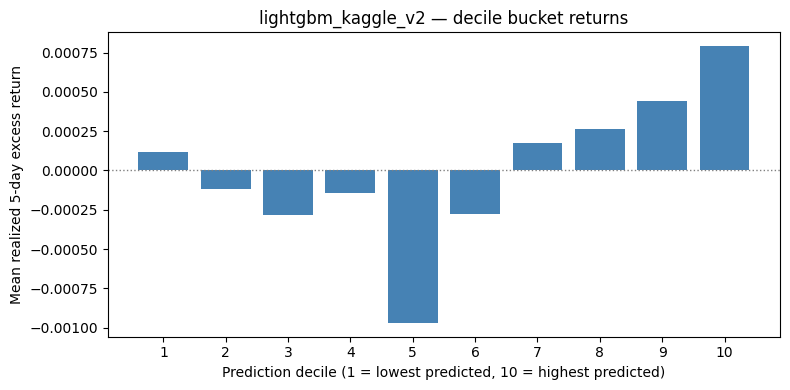

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(deciles["bucket"], deciles["mean_realized"], color="steelblue")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Prediction decile (1 = lowest predicted, 10 = highest predicted)")
ax.set_ylabel("Mean realized 5-day excess return")
ax.set_title(f"{MODEL_ID} — decile bucket returns")
ax.set_xticks(list(deciles["bucket"]))
plt.tight_layout()
plt.show()

**Sanity check:** the difference between the top-decile mean and the bottom-decile mean is the cross-sectional return spread the model is harvesting. If this is *positive and persistent*, the long-short Sharpe from the headline table is built on a real foundation.

In [7]:
if deciles.height >= 10:
    spread = float(deciles["mean_realized"].max() - deciles["mean_realized"].min())
    print(f"Top-decile minus bottom-decile mean realized return: {spread:+.5f}")
    print(f"({spread * 100:+.3f}% per 5-day window across the cross-section)")

Top-decile minus bottom-decile mean realized return: +0.00176
(+0.176% per 5-day window across the cross-section)


## 3) Time-split evaluation

Walk-forward predictions are already out-of-sample by construction — each prediction was made by a model fit on data strictly before that date. So splitting the prediction sample by date isn't a re-fit, it's a *partition*. The check is: does the model's edge hold up in both halves, or did it concentrate in one regime?

We pick the cutoff to split the sample roughly in half by date count.

In [8]:
all_dates = sorted(eval_df["date"].unique().to_list())
mid_idx = len(all_dates) // 2
cutoff = all_dates[mid_idx]
print(f"Cutoff: {cutoff}")

split = time_split_evaluate(eval_df, cutoff=cutoff, horizon_days=HORIZON)
split.as_frame()

Cutoff: 2022-10-10


window,n_observations,n_dates,information_coefficient,ic_t_stat,hit_rate,mae,rmse,long_short_sharpe
str,i64,i64,f64,f64,f64,f64,f64,f64
"""2019-03-05 → 2022-10-07""",145280,908,-0.004055,-0.960563,0.497825,0.025782,0.037534,-0.314095
"""2022-10-10 → 2026-05-22""",144640,904,0.019083,4.606255,0.506533,0.025779,0.036935,0.967485


**How to read this table:**
- If `information_coefficient` and `long_short_sharpe` are both positive in *both* windows, the edge replicates — it's not a single-regime artifact.
- If IC is strong in window A but ~0 (or negative) in window B, the model's edge **decayed** — likely because the market structure changed (e.g., the 2020 vol regime, post-2022 mega-cap concentration) and the features that worked don't anymore.
- If IC is similar but t-stat differs a lot, that's just the sample-size effect: window B might have fewer dates if predictions started later.

**Three additional date cutoffs to try yourself** for a more granular regime view:
- `2020-01-01` — pre-COVID vs post-COVID
- `2022-01-01` — pre vs post the mega-cap concentration phase
- `2024-01-01` — most recent 2 years only

## Takeaways

Fill in based on the actual numbers above. The interview-quality version of the conclusion looks like:

> `lightgbm_kaggle_v2` achieves IC = `{point}` with bootstrap 95% CI [`{p05}`, `{p95}`]. The 10-decile bucket plot is monotonic ascending (top minus bottom = `{spread}`), confirming the IC reflects real cross-sectional ranking rather than a tail-only effect. Time-split evaluation across `{cutoff}` shows IC = `{ic_a}` / `{ic_b}` in the two halves — the edge is `{stable | decaying | concentrated}` over time.

If any of the three checks fails (CI crosses zero, bucket plot flat or non-monotonic, time-split shows decay), the right thing is to say so explicitly rather than rely on the headline number alone.